# Neuron Model

## [Transfer Functions](https://engineer-e.github.io/Neural-Network/Neural_Network_Design_2e/Ch2/theory_and_examples/neuron_model/transfer_function.html)

1. The transfer function in *Figure 2.1* way be a linear or a non linear function of *n*. 
2. A particular transfer function is chosen to satisfy some specification of the problem that the neuron is attempting to solve. 
3. A variety of transfer function have been included in this book. 
4. Three of the most commonly used functions are discussed below.
   - Hard Limit Transfer Function
   - Linear Transfer Function
   - Log-Sigmoid Transfer Function

### Hard Limit Transfer Function

1. The *hard limit transfer function*, shown on the left side of Figure 2.2, sets the output of the neuron to 0. If the function argument is less than 0, or 1 if its arguments is greater than or equal to 0.

$$ \displaystyle \mathbb{Hard\enspace Limit \enspace Transfer \enspace Function } = \begin{cases}
   0 &\text{if } n < 0 \\
   1 &\text{if } n ≥ 0
\end{cases}$$

2. We will use this function to create neurons that classify inputs into two distinct categories. 
3. It will be extensively in Chapter 4.

#### Figure 2.2 Hard Limit Transfer Function

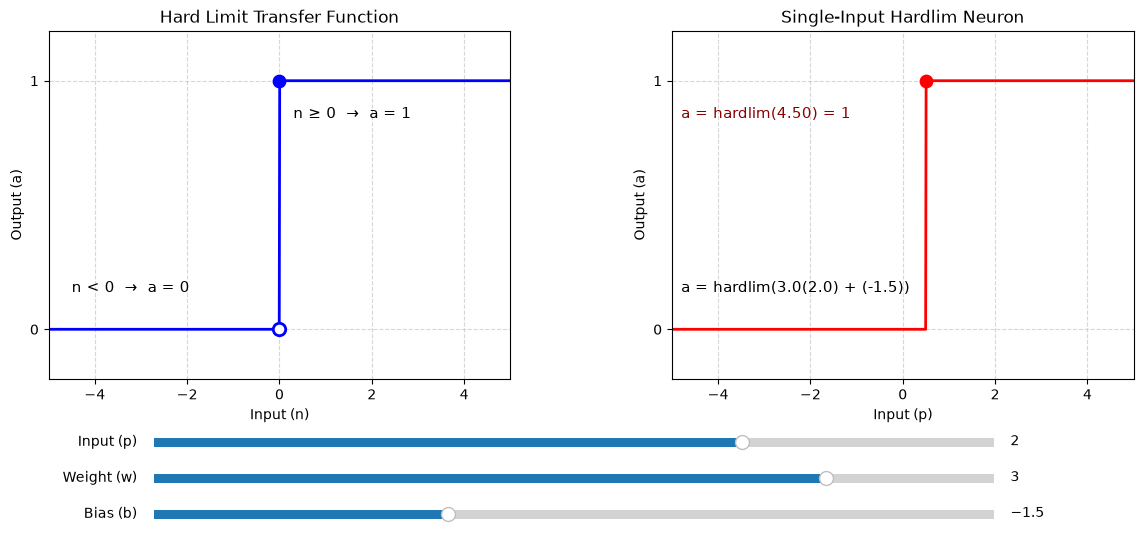

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ============================================================
# Hard Limit Transfer Function
# ============================================================

n = np.linspace(-5, 5, 1000)
a = np.where(n < 0, 0, 1)

# Initial values
p0 = 2.0
w0 = 3.0
b0 = -1.5

# ============================================================
# Create Figure
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Leave space at bottom for sliders
plt.subplots_adjust(bottom=0.30, wspace=0.35)

# ============================================================
# CHART 1: Hard Limit Transfer Function
# ============================================================

ax1.plot(n, a, color="blue", linewidth=2)

# Open circle at (0,0)
ax1.scatter(
    0, 0,
    facecolors="white",
    edgecolors="blue",
    s=80,
    linewidth=2,
    zorder=5
)

# Filled circle at (0,1)
ax1.scatter(
    0, 1,
    color="blue",
    s=80,
    zorder=5
)

ax1.set_title("Hard Limit Transfer Function")
ax1.set_xlabel("Input (n)")
ax1.set_ylabel("Output (a)")
ax1.set_xlim(-5, 5)
ax1.set_ylim(-0.2, 1.2)
ax1.set_yticks([0, 1])
ax1.grid(True, linestyle="--", alpha=0.5)

ax1.text(-4.5, 0.15, "n < 0  →  a = 0", fontsize=11)
ax1.text(0.3, 0.85, "n ≥ 0  →  a = 1", fontsize=11)

# ============================================================
# CHART 2: Single-Input Hardlim Neuron
# ============================================================

p = np.linspace(-5, 5, 1000)

net = w0 * p + b0
output = np.where(net < 0, 0, 1)

line2, = ax2.plot(
    p,
    output,
    color="red",
    linewidth=2
)

# Threshold
threshold = -b0 / w0

threshold_point = ax2.scatter(
    threshold,
    1,
    color="red",
    s=80,
    zorder=5
)

ax2.set_title("Single-Input Hardlim Neuron")
ax2.set_xlabel("Input (p)")
ax2.set_ylabel("Output (a)")
ax2.set_xlim(-5, 5)
ax2.set_ylim(-0.2, 1.2)
ax2.set_yticks([0, 1])
ax2.grid(True, linestyle="--", alpha=0.5)

# Equation text
equation_text = ax2.text(
    -4.8,
    0.15,
    "",
    fontsize=11
)

output_text = ax2.text(
    -4.8,
    0.85,
    "",
    fontsize=11,
    color="darkred"
)

# ============================================================
# SLIDERS
# ============================================================

# Input slider
ax_p = plt.axes([0.20, 0.18, 0.60, 0.03])
slider_p = Slider(
    ax=ax_p,
    label="Input (p)",
    valmin=-5,
    valmax=5,
    valinit=p0,
    valstep=0.1
)

# Weight slider
ax_w = plt.axes([0.20, 0.12, 0.60, 0.03])
slider_w = Slider(
    ax=ax_w,
    label="Weight (w)",
    valmin=-5,
    valmax=5,
    valinit=w0,
    valstep=0.1
)

# Bias slider
ax_b = plt.axes([0.20, 0.06, 0.60, 0.03])
slider_b = Slider(
    ax=ax_b,
    label="Bias (b)",
    valmin=-5,
    valmax=5,
    valinit=b0,
    valstep=0.1
)

# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(val):

    # Get slider values
    p_value = slider_p.val
    w_value = slider_w.val
    b_value = slider_b.val

    # Calculate net input
    net_value = w_value * p_value + b_value

    # Hard limit activation
    output_value = 0 if net_value < 0 else 1

    # Update neuron graph
    net_graph = w_value * p + b_value
    output_graph = np.where(net_graph < 0, 0, 1)

    line2.set_ydata(output_graph)

    # Update threshold
    if w_value != 0:
        threshold = -b_value / w_value
        threshold = np.clip(threshold, -5, 5)

        threshold_point.set_offsets(
            [[threshold, 1]]
        )

    # Update equation
    equation_text.set_text(
        f"a = hardlim({w_value:.1f}({p_value:.1f}) + ({b_value:.1f}))"
    )

    output_text.set_text(
        f"a = hardlim({net_value:.2f}) = {output_value}"
    )

    fig.canvas.draw_idle()


# Connect sliders
slider_p.on_changed(update)
slider_w.on_changed(update)
slider_b.on_changed(update)

# Initial display
update(None)

plt.show()

4. The graph on the right side of Figure 2.2 illustrates the input/output characteristic of a single-input neuron that uses a hard limit transfer function.
5. Here we can see the effect of the weight and the bias.
6. Note that an icon for the hard limit transfer function is shown between the two figures.
7. Such icons will replace the general *f* in the network diagrams to show the particular transfer function that is being used.

### Linear Transfer Function


1. The output of a *linear transfer function* is equal to its input: $\boxed{a=n}$, as illustrated in Figure 2.3.
2. Neurons with this transfer function are used in the ADALINE networks, which are discussed in Chapter 10.
3. The output (*a*) versus input (*p*) characteristic of a single-input linear neuron with a bias is shown on the right of Figure 2.3.

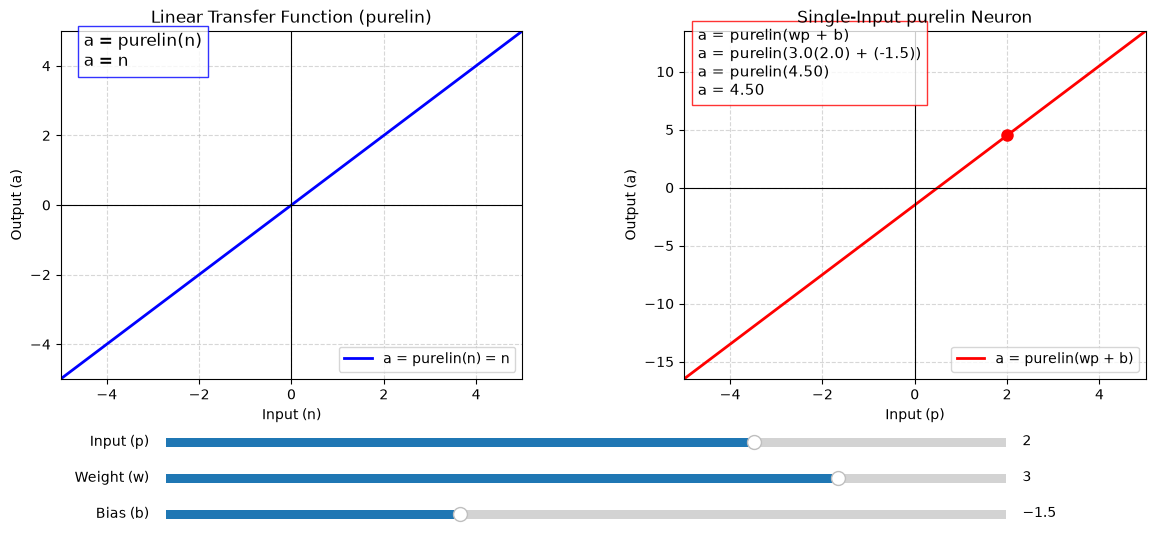

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ============================================================
# INITIAL VALUES
# ============================================================

p0 = 2.0
w0 = 3.0
b0 = -1.5

# ============================================================
# CREATE FIGURE WITH 2 CHARTS
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Space for sliders
plt.subplots_adjust(bottom=0.30, wspace=0.35)

# ============================================================
# CHART 1: LINEAR TRANSFER FUNCTION
# ============================================================

n = np.linspace(-5, 5, 500)

# purelin(n) = n
a = n

ax1.plot(
    n,
    a,
    color="blue",
    linewidth=2,
    label="a = purelin(n) = n"
)

ax1.set_title("Linear Transfer Function (purelin)")
ax1.set_xlabel("Input (n)")
ax1.set_ylabel("Output (a)")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.axvline(0, color="black", linewidth=0.8)

ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)

# Equation on chart
ax1.text(
    -4.5,
    4,
    "a = purelin(n)\na = n",
    fontsize=12,
    bbox=dict(
        facecolor="white",
        edgecolor="blue",
        alpha=0.8
    )
)

# ============================================================
# CHART 2: SINGLE-INPUT PURELIN NEURON
# ============================================================

p = np.linspace(-5, 5, 500)

# Initial neuron equation
net = w0 * p + b0
output = net

line2, = ax2.plot(
    p,
    output,
    color="red",
    linewidth=2,
    label="a = purelin(wp + b)"
)

ax2.set_title("Single-Input purelin Neuron")
ax2.set_xlabel("Input (p)")
ax2.set_ylabel("Output (a)")

ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(0, color="black", linewidth=0.8)

ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

ax2.set_xlim(-5, 5)
ax2.set_ylim(-10, 10)

# Current point on neuron
current_point, = ax2.plot(
    [p0],
    [w0 * p0 + b0],
    "ro",
    markersize=8
)

# Equation text
equation_text = ax2.text(
    -4.7,
    8,
    "",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="red",
        alpha=0.8
    )
)

# ============================================================
# SLIDER 1: INPUT (p)
# ============================================================

ax_p = plt.axes(
    [0.20, 0.18, 0.60, 0.03]
)

slider_p = Slider(
    ax=ax_p,
    label="Input (p)",
    valmin=-5,
    valmax=5,
    valinit=p0,
    valstep=0.1
)

# ============================================================
# SLIDER 2: WEIGHT (w)
# ============================================================

ax_w = plt.axes(
    [0.20, 0.12, 0.60, 0.03]
)

slider_w = Slider(
    ax=ax_w,
    label="Weight (w)",
    valmin=-5,
    valmax=5,
    valinit=w0,
    valstep=0.1
)

# ============================================================
# SLIDER 3: BIAS (b)
# ============================================================

ax_b = plt.axes(
    [0.20, 0.06, 0.60, 0.03]
)

slider_b = Slider(
    ax=ax_b,
    label="Bias (b)",
    valmin=-5,
    valmax=5,
    valinit=b0,
    valstep=0.1
)

# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(val):

    # Get slider values
    p_value = slider_p.val
    w_value = slider_w.val
    b_value = slider_b.val

    # --------------------------------------------------------
    # Calculate net input
    # n = wp + b
    # --------------------------------------------------------

    n_value = w_value * p_value + b_value

    # --------------------------------------------------------
    # purelin activation
    # a = n
    # --------------------------------------------------------

    a_value = n_value

    # --------------------------------------------------------
    # Update second graph
    # --------------------------------------------------------

    new_output = w_value * p + b_value

    line2.set_ydata(new_output)

    # --------------------------------------------------------
    # Update current point
    # --------------------------------------------------------

    current_point.set_data(
        [p_value],
        [a_value]
    )

    # --------------------------------------------------------
    # Update equation displayed on graph
    # --------------------------------------------------------

    equation_text.set_text(
        f"a = purelin(wp + b)\n"
        f"a = purelin({w_value:.1f}({p_value:.1f}) + ({b_value:.1f}))\n"
        f"a = purelin({n_value:.2f})\n"
        f"a = {a_value:.2f}"
    )

    # Automatically adjust Y-axis
    ymin = min(-10, np.min(new_output))
    ymax = max(10, np.max(new_output))

    ax2.set_ylim(ymin, ymax)

    fig.canvas.draw_idle()


# Connect sliders to update function
slider_p.on_changed(update)
slider_w.on_changed(update)
slider_b.on_changed(update)

# Initial update
update(None)

plt.show()

### Log-Sigmoid Transfer Function

1. The *log-sigmoid transfer function* is shown in Figure 2.4.
2. This transfer function takes the input ( which may have any value between plus and minus infinity ($\infty$) ) and squashes the output into the range 0 to 1, according to the expression: 
 $$ \displaystyle a = \frac{1}{1+e^{(-n)}}$$
3. The log-sigmoid transfer function is commonly using in multilayer networks that are trained using the backpropagation algorithm, in part because this function is differentiable (see Chapter 11).
4. Most of the *transfer functions* used in this book are summarized in **Table 2.1.**.
5. Of Course, you can define other transfer functions in addition to those shown in *Table 2.1*. if you wish.

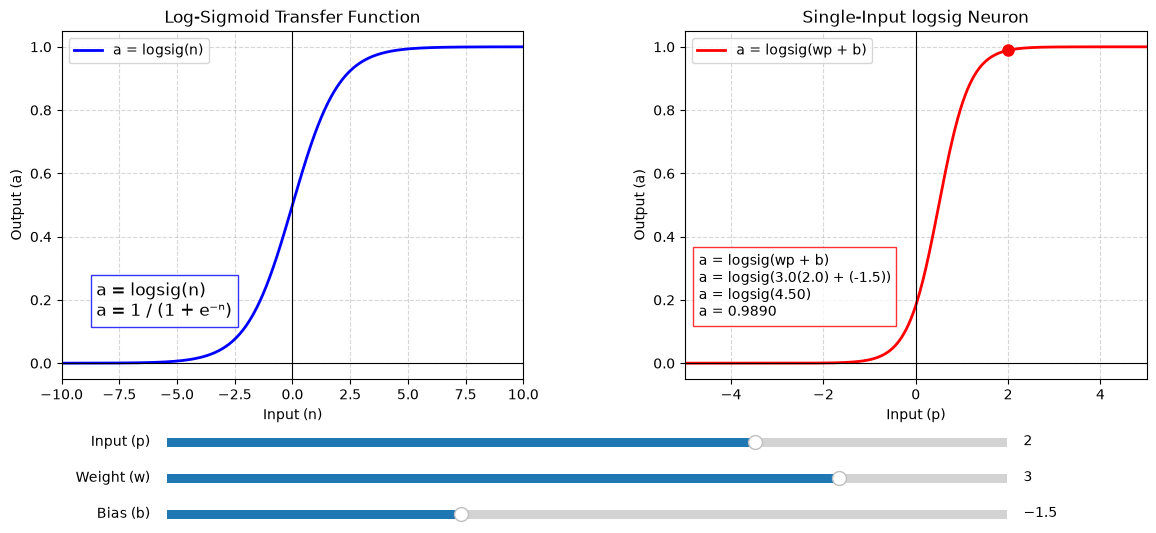

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ============================================================
# LOG-SIGMOID TRANSFER FUNCTION
# ============================================================

def logsig(n):
    return 1 / (1 + np.exp(-n))


# ============================================================
# INITIAL VALUES
# ============================================================

p0 = 2.0
w0 = 3.0
b0 = -1.5


# ============================================================
# CREATE FIGURE WITH 2 CHARTS
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Space for sliders
plt.subplots_adjust(bottom=0.30, wspace=0.35)


# ============================================================
# CHART 1: LOG-SIGMOID TRANSFER FUNCTION
# ============================================================

n = np.linspace(-10, 10, 1000)

# a = logsig(n)
a = logsig(n)

ax1.plot(
    n,
    a,
    color="blue",
    linewidth=2,
    label="a = logsig(n)"
)

ax1.set_title("Log-Sigmoid Transfer Function")
ax1.set_xlabel("Input (n)")
ax1.set_ylabel("Output (a)")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.axvline(0, color="black", linewidth=0.8)

ax1.grid(True, linestyle="--", alpha=0.5)

ax1.set_xlim(-10, 10)
ax1.set_ylim(-0.05, 1.05)

ax1.legend()

# Equation
ax1.text(
    -8.5,
    0.15,
    "a = logsig(n)\n"
    "a = 1 / (1 + e⁻ⁿ)",
    fontsize=12,
    bbox=dict(
        facecolor="white",
        edgecolor="blue",
        alpha=0.8
    )
)


# ============================================================
# CHART 2: SINGLE-INPUT LOGSIG NEURON
# ============================================================

p = np.linspace(-5, 5, 1000)

# n = wp + b
net = w0 * p + b0

# a = logsig(wp+b)
output = logsig(net)

line2, = ax2.plot(
    p,
    output,
    color="red",
    linewidth=2,
    label="a = logsig(wp + b)"
)

ax2.set_title("Single-Input logsig Neuron")
ax2.set_xlabel("Input (p)")
ax2.set_ylabel("Output (a)")

ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(0, color="black", linewidth=0.8)

ax2.grid(True, linestyle="--", alpha=0.5)

ax2.set_xlim(-5, 5)
ax2.set_ylim(-0.05, 1.05)

ax2.legend()

# Current input/output point
current_point, = ax2.plot(
    [p0],
    [logsig(w0 * p0 + b0)],
    "ro",
    markersize=8
)

# Equation text
equation_text = ax2.text(
    -4.7,
    0.15,
    "",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="red",
        alpha=0.8
    )
)


# ============================================================
# SLIDER 1: INPUT (p)
# ============================================================

ax_p = plt.axes(
    [0.20, 0.18, 0.60, 0.03]
)

slider_p = Slider(
    ax=ax_p,
    label="Input (p)",
    valmin=-5,
    valmax=5,
    valinit=p0,
    valstep=0.1
)


# ============================================================
# SLIDER 2: WEIGHT (w)
# ============================================================

ax_w = plt.axes(
    [0.20, 0.12, 0.60, 0.03]
)

slider_w = Slider(
    ax=ax_w,
    label="Weight (w)",
    valmin=-5,
    valmax=5,
    valinit=w0,
    valstep=0.1
)


# ============================================================
# SLIDER 3: BIAS (b)
# ============================================================

ax_b = plt.axes(
    [0.20, 0.06, 0.60, 0.03]
)

slider_b = Slider(
    ax=ax_b,
    label="Bias (b)",
    valmin=-5,
    valmax=5,
    valinit=b0,
    valstep=0.1
)


# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(val):

    # Get slider values
    p_value = slider_p.val
    w_value = slider_w.val
    b_value = slider_b.val

    # --------------------------------------------------------
    # Net input
    # n = wp + b
    # --------------------------------------------------------

    n_value = w_value * p_value + b_value

    # --------------------------------------------------------
    # Log-sigmoid activation
    # a = 1 / (1 + e^(-n))
    # --------------------------------------------------------

    a_value = logsig(n_value)

    # --------------------------------------------------------
    # Update neuron graph
    # --------------------------------------------------------

    new_net = w_value * p + b_value
    new_output = logsig(new_net)

    line2.set_ydata(new_output)

    # --------------------------------------------------------
    # Update current point
    # --------------------------------------------------------

    current_point.set_data(
        [p_value],
        [a_value]
    )

    # --------------------------------------------------------
    # Update equation on graph
    # --------------------------------------------------------

    equation_text.set_text(
        f"a = logsig(wp + b)\n"
        f"a = logsig({w_value:.1f}({p_value:.1f}) + ({b_value:.1f}))\n"
        f"a = logsig({n_value:.2f})\n"
        f"a = {a_value:.4f}"
    )

    fig.canvas.draw_idle()


# ============================================================
# CONNECT SLIDERS
# ============================================================

slider_p.on_changed(update)
slider_w.on_changed(update)
slider_b.on_changed(update)


# Initial update
update(None)

plt.show()

# **Table 2.1: Transfer Functions**

| **Name**                    | **Input/Output Relation**                 | **Icon** | **MATLAB Function** |
| --------------------------- | ----------------------------------------- | -------- | ------------------- |
| Hard Limit                  | $$ \displaystyle \mathbb{a} = \begin{cases} 0 &\text{if } n < 0 \\   1 &\text{if } n ≥ 0\end{cases}$$ |  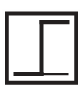        |`hardlim`|
| Symmetrical Hard Limit      | $$ \displaystyle \mathbb{a} = \begin{cases} -1 &\text{if } n < 0 \\   +1 &\text{if } n ≥ 0\end{cases}$$ |  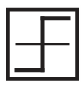      | `hardlims`          |
| Linear                      | $$ \displaystyle a= n$$ |  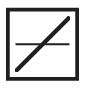      | `purelin`           |
| Saturating Linear           |  $$ \displaystyle \mathbb{a} = \begin{cases} 0 &\text{if } n < 0 \\   n &\text{if } 0≤ n ≤ 1 \\   1 &\text{if } n > 1  \end{cases}$$     |  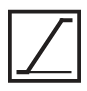      | `satlin`            |
| Symmetric Saturating Linear | $$ \displaystyle \mathbb{a} = \begin{cases} -1 &\text{if } n < -1 \\   n &\text{if } -1 ≤ n ≤ 1 \\   1 &\text{if } n > 1  \end{cases}$$           |  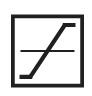      | `satlins`           |
| Log-Sigmoid                 | $$\displaystyle a = \frac{1}{1+e^{-n}}$$                    |  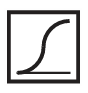      | `logsig`            |
| Hyperbolic Tangent Sigmoid  |  $$\displaystyle a = \frac{e^n-e^{-n}}{e^n+e^{-n}}$$          | 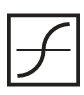       | `tansig`            |
| Positive Linear             |    $$ \displaystyle \mathbb{a} = \begin{cases} 0 &\text{if } n < 0 \\   n &\text{if } n ≥ 0\end{cases}$$     |    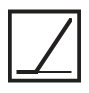   | `poslin`            |
| Competitive                 |$$ \displaystyle \mathbb{a} = \begin{cases} 1 &\text{if, } neuron \enspace with \enspace max \enspace (n) \\   0 &\text{if, } all \enspace other \enspace neurons \end{cases}$$ |  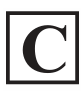      | `compet`            |

